# QICK RFSoC client (JupyterLab, runs on your PC)

Talks to the ZCU216 over Pyro. The board must already be running `rfsoc_pyro_server.ipynb`.

**Kernel:** select the conda env that has `qick==0.2.422`, `Pyro4`, `psutil`. If it is missing from JupyterLab's kernel list, run once inside the env:
`pip install ipykernel` then `python -m ipykernel install --user --name qick-client --display-name "qick-client"`.

Run the cells in order. Cells 1 to 6 only define things; the "Run" sections at the bottom do the work.
**Interrupt (■ button)** stops a run that is waiting for a trigger; the `finally` blocks disarm the tProc and reset the generators.

## 1. Settings

In [1]:
import qick
from qick.asm_v2 import AveragerProgramV2
print(qick.__file__)                                       # should be under C:\qick_board
print('axis_sg_mixmux16_v1' in AveragerProgramV2.gentypes) # should be True

C:\qick_board\qick\__init__.py
True


C:\Users\abhim\anaconda3\envs\qick_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time
from dataclasses import dataclass, field
from typing import Callable, List, Optional

from qick.asm_v2 import AveragerProgramV2
from qick.pyro import make_proxy

NS_HOST = "192.168.2.100"     # <-- IP address of the ZCU216
# run the following command on the host to extract ip address of zcu216
#!hostname -I
#!ip -4 addr show
NS_PORT = 8888
PROXY_NAME = "myqick"

GEN_CH = 7
MIXER_FREQ = 0
TONE_FREQS = [199.2, 199.3, 199.4, 199.5, 199.6, 199.7, 199.8, 199.9,
              200.0, 200.1, 200.2, 200.3, 200.4, 200.5, 200.6, 200.7]   # MHz, absolute (tProc v2)
TONE_GAINS = [0.0625] * 16
TONE_PHASES = [0] * 16
ALL_TONES = list(range(16))

## 2. Your original notebook program

In [3]:
class MixMuxProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch, gen_ch = cfg['ro_ch'], cfg['gen_ch']
        self.declare_gen(ch=gen_ch, nqz=1, ro_ch=ro_ch, mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['pulse_freqs'][0],
                               phase=cfg['ro_phase'], gen_ch=gen_ch)
        self.add_pulse(ch=gen_ch, name="mymixmux", style="const",
                       length=cfg["pulse_len"], mask=cfg['pulse_mask'])

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name="mymixmux", t=0)


def run_original_test(soc, soccfg, pulse_len_us=4_000_000.0):
    config = {'gen_ch': GEN_CH, 'ro_ch': 0, 'mixer_freq': MIXER_FREQ,
              'pulse_freqs': TONE_FREQS, 'pulse_gains': TONE_GAINS,
              'pulse_phases': TONE_PHASES, 'pulse_mask': ALL_TONES,
              'ro_phase': 0.0, 'trig_time': 0.4, 'pulse_len': pulse_len_us, 'ro_len': 1.9}
    prog = MixMuxProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    try:
        return prog.acquire_decimated(soc, rounds=1)
    finally:
        soc.reset_gens()

## 3. Shot builder (multi-channel)
A **shot** is a list of `Channel` objects that all start together at the beginning of the shot.
Each `Channel` has its own generator, tones, gains, optional start delay, and its own list of `on(...)` / `off(...)` segments.
(The old single-channel form, a plain list of segments, still works: it plays on `GEN_CH` with `TONE_*`.)

In [4]:
@dataclass
class Seg:
    is_on: bool
    dur_us: float
    tones: Optional[List[int]] = None     # MUX gens only: which declared tones play in this segment (None = all)
    freq: Optional[float] = None          # single-tone gens only: per-segment override (MHz)
    gain: Optional[float] = None          # single-tone gens only
    phase: Optional[float] = None         # single-tone gens only (deg)

def on(dur_us, tones=None, freq=None, gain=None, phase=None):
    return Seg(True, float(dur_us), tones, freq, gain, phase)

def off(dur_us):
    return Seg(False, float(dur_us))


@dataclass
class Channel:
    """One generator's part of a shot."""
    gen_ch: int                            # index in the firmware 'gens' list (see describe_gens)
    segments: List[Seg]
    freqs: List[float]                     # MUX gen: list of tone freqs (MHz, absolute). Single-tone gen: [freq]
    gains: Optional[List[float]] = None    # MUX default 0.0625 per tone; single-tone default 0.5
    phases: Optional[List[float]] = None   # degrees, default 0
    nqz: int = 1
    mixer_freq: Optional[float] = None     # MHz; None -> MIXER_FREQ for mux gens, unset for single-tone gens
    delay_us: float = 0.0                  # start offset of this channel inside the shot


def _as_channels(shot):
    """Accept either a list of Channel or the legacy list of Seg (wrapped onto GEN_CH)."""
    if len(shot) > 0 and isinstance(shot[0], Seg):
        return [Channel(GEN_CH, shot, TONE_FREQS, TONE_GAINS, TONE_PHASES, nqz=1, mixer_freq=MIXER_FREQ)]
    return list(shot)

def channel_length_us(c):
    return c.delay_us + sum(s.dur_us for s in c.segments)

def shot_length_us(shot):
    """Length of the shot = the longest channel (start delay included)."""
    if len(shot) > 0 and isinstance(shot[0], Seg):
        return sum(s.dur_us for s in shot)
    return max(channel_length_us(c) for c in shot)


def describe_gens(soccfg):
    """Which generator index is which type, and where it comes out."""
    for i, g in enumerate(soccfg['gens']):
        kind = f"mux, {g['n_tones']} tones" if 'n_tones' in g else "single tone"
        print(f"gen {i:2d}: {g.get('type')}  [{kind}]  dac={g.get('dac')}  mixer={'yes' if g.get('has_mixer') else 'no'}")


def validate_shot(soccfg, channels):
    """Fail early, with a readable message, instead of deep inside QICK."""
    gens = soccfg['gens']
    seen = set()
    for c in channels:
        if c.gen_ch in seen:
            raise ValueError(f"gen channel {c.gen_ch} appears twice in the shot; merge them into one Channel")
        seen.add(c.gen_ch)
        if not 0 <= c.gen_ch < len(gens):
            raise ValueError(f"gen channel {c.gen_ch} does not exist (firmware has {len(gens)} gens)")
        g = gens[c.gen_ch]
        if 'n_tones' in g:
            if len(c.freqs) > g['n_tones']:
                raise ValueError(f"gen {c.gen_ch}: {len(c.freqs)} tones requested, max {g['n_tones']}")
            for s in c.segments:
                if s.freq is not None or s.gain is not None or s.phase is not None:
                    raise ValueError(f"gen {c.gen_ch} is a mux gen: per-segment freq/gain/phase not allowed (use tones=[...])")
                if s.tones and max(s.tones) >= len(c.freqs):
                    raise ValueError(f"gen {c.gen_ch}: segment uses tone {max(s.tones)} but only {len(c.freqs)} tones declared")
        else:
            for s in c.segments:
                if s.tones is not None:
                    raise ValueError(f"gen {c.gen_ch} is a single-tone gen: 'tones=' not allowed (use freq/gain/phase)")
            if len(c.freqs) < 1:
                raise ValueError(f"gen {c.gen_ch}: give at least one frequency")

### 3b. Independent tones (up to 16 per generator)
A mux generator holds up to 16 tones. Each tone has its **own frequency, gain, phase and its own on/off intervals**, and all 16 run simultaneously.

How it works: gain, phase and frequency of each tone are programmed once per program run; a pulse only chooses *which tones are gated on* (a mask). So `compile_tones` cuts the timeline at every tone edge and plays, for each piece, one pulse whose mask is the set of tones that are on. Edges are snapped to the generator clock grid so the pieces abut exactly.

Consequences: changing a tone's freq/gain/phase means building a new program (fine between scan points, not within a shot); on/off timing is fully independent per tone.

In [5]:
@dataclass
class Tone:
    """One independently configured tone of a mux generator."""
    freq: float                       # MHz, absolute
    gain: float = 0.0625
    phase: float = 0.0                # degrees
    intervals: List[tuple] = field(default_factory=list)   # (start_us, dur_us), relative to channel start

    def add(self, start_us, dur_us):
        self.intervals.append((float(start_us), float(dur_us)))
        return self

    def train(self, start_us, on_us, off_us, n):
        """n pulses of on_us separated by off_us, the first at start_us."""
        for k in range(n):
            self.add(start_us + k * (on_us + off_us), on_us)
        return self


def compile_tones(soccfg, gen_ch, tones, nqz=1, mixer_freq=None, delay_us=0.0, min_cycles=3):
    """Per-tone intervals -> a Channel of back-to-back mask segments (see the note above)."""
    g = soccfg['gens'][gen_ch]
    if 'n_tones' not in g:
        raise ValueError(f"gen {gen_ch} is not a mux generator")
    if len(tones) > g['n_tones']:
        raise ValueError(f"gen {gen_ch}: {len(tones)} tones given, max {g['n_tones']}")
    to_c = lambda us: soccfg.us2cycles(us, gen_ch=gen_ch)
    to_us = lambda c: soccfg.cycles2us(c, gen_ch=gen_ch)

    spans = []                                    # per tone: list of (c0, c1) in clock cycles
    for i, t in enumerate(tones):
        sp = []
        for (s, d) in t.intervals:
            if d <= 0 or s < 0:
                raise ValueError(f"tone {i}: bad interval start={s}, dur={d}")
            c0, c1 = to_c(s), to_c(s + d)
            if c1 <= c0:
                raise ValueError(f"tone {i}: interval ({s}, {d}) us is shorter than one clock cycle")
            sp.append((c0, c1))
        spans.append(sp)

    freqs, gains, phases = [t.freq for t in tones], [t.gain for t in tones], [t.phase for t in tones]
    edges = sorted({c for sp in spans for (c0, c1) in sp for c in (c0, c1)})
    segs = []
    if edges:
        pieces = []                               # (c0, c1, tuple(active tone indices))
        for a, b in zip(edges[:-1], edges[1:]):
            active = tuple(i for i, sp in enumerate(spans) if any(c0 <= a < c1 for (c0, c1) in sp))
            if pieces and pieces[-1][2] == active and pieces[-1][1] == a:
                pieces[-1] = (pieces[-1][0], b, active)
            else:
                pieces.append((a, b, active))
        if edges[0] > 0:
            segs.append(off(to_us(edges[0])))
        for (a, b, active) in pieces:
            if active and (b - a) < min_cycles:
                raise ValueError(f"gen {gen_ch}: a piece with tones {list(active)} lasts only {b-a} cycle(s) "
                                 f"({to_us(b-a)*1e3:.1f} ns); minimum is {min_cycles}. Move nearby tone edges apart.")
            segs.append(on(to_us(b - a), tones=list(active)) if active else off(to_us(b - a)))
    return Channel(gen_ch, segs, freqs, gains, phases, nqz, mixer_freq, delay_us)


def show_schedule(channel, n=12):
    """Print the first n pieces the generator will play."""
    t = channel.delay_us
    for i, s in enumerate(channel.segments[:n]):
        what = f"ON  tones {s.tones}" if s.is_on else "off"
        print(f"  {t:9.3f} us  +{s.dur_us:8.3f} us  {what}")
        t += s.dur_us
    if len(channel.segments) > n:
        print(f"  ... {len(channel.segments) - n} more pieces ({sum(x.is_on for x in channel.segments)} pulses total)")


def plot_tones(tones, title=""):
    """Raster of every tone's on-intervals (your intent, before compilation)."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 0.28 * len(tones) + 1.2))
    for k, t in enumerate(tones):
        for (s, d) in t.intervals:
            ax.barh(k, d, left=s, height=0.7)
    ax.set_yticks(range(len(tones)))
    ax.set_yticklabels([f"{k}: {t.freq:.2f} MHz" for k, t in enumerate(tones)], fontsize=7)
    ax.set_xlabel("time in shot (us)")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 4. Program that plays one multi-channel shot per iteration

In [6]:
class SequenceProgram(AveragerProgramV2):
    """cfg keys: channels (list of Channel), gap_us (idle time after every shot),
    marker_pin (output pin index or None)."""

    def _initialize(self, cfg):
        for c in cfg['channels']:
            gcfg = self.soccfg['gens'][c.gen_ch]
            is_mux = 'n_tones' in gcfg
            if is_mux:
                n = len(c.freqs)
                self.declare_gen(ch=c.gen_ch, nqz=c.nqz,
                                 mixer_freq=c.mixer_freq if c.mixer_freq is not None else MIXER_FREQ,
                                 mux_freqs=c.freqs,
                                 mux_gains=c.gains if c.gains is not None else [0.0625] * n,
                                 mux_phases=c.phases if c.phases is not None else [0] * n)
            else:
                kw = {}
                if gcfg.get('has_mixer') and c.mixer_freq is not None:
                    kw['mixer_freq'] = c.mixer_freq
                self.declare_gen(ch=c.gen_ch, nqz=c.nqz, **kw)

            for i, s in enumerate(c.segments):
                if not s.is_on:
                    continue
                name = f"c{c.gen_ch}_s{i}"
                if is_mux:
                    mask = s.tones if s.tones is not None else list(range(len(c.freqs)))
                    self.add_pulse(ch=c.gen_ch, name=name, style="const", length=s.dur_us, mask=mask)
                else:
                    self.add_pulse(ch=c.gen_ch, name=name, style="const", length=s.dur_us,
                                   freq=s.freq if s.freq is not None else c.freqs[0],
                                   gain=s.gain if s.gain is not None else (c.gains[0] if c.gains else 0.5),
                                   phase=s.phase if s.phase is not None else (c.phases[0] if c.phases else 0.0))

    def _body(self, cfg):
        total = shot_length_us(cfg['channels'])
        if cfg.get('marker_pin') is not None:
            # digital marker high for the whole shot; pin index from print(soccfg)
            self.trigger(pins=[cfg['marker_pin']], t=0, width=total)
        for c in cfg['channels']:
            t = c.delay_us
            for i, s in enumerate(c.segments):
                if s.is_on:
                    self.pulse(ch=c.gen_ch, name=f"c{c.gen_ch}_s{i}", t=t)
                t += s.dur_us
        # advance the timeline past the whole shot (longest channel) plus the gap
        self.delay(total + cfg['gap_us'])


def make_sequence_program(soccfg, shot, reps=1, gap_us=1.0, marker_pin=None):
    channels = _as_channels(shot)
    validate_shot(soccfg, channels)
    cfg = {'channels': channels, 'gap_us': gap_us, 'marker_pin': marker_pin}
    # final_delay=None: the body already advances the timeline itself
    return SequenceProgram(soccfg, reps=reps, final_delay=None, cfg=cfg)

## 5. Ways to repeat the shot

In [7]:
def run_hardware_reps(soc, soccfg, shot, n_shots, **kw):
    """Fastest: the tProc repeats the shot n_shots times back-to-back after one internal start."""
    prog = make_sequence_program(soccfg, shot, reps=n_shots, **kw)
    try:
        prog.run_rounds(soc, rounds=1, start_src="internal", progress=False)
    finally:
        soc.reset_gens()


def run_python_loop(soc, soccfg, shot, n_shots, per_shot=None, **kw):
    """One shot per Python iteration, internal start. Use when the host must act between shots."""
    prog = make_sequence_program(soccfg, shot, reps=1, **kw)
    try:
        for i in range(n_shots):
            if per_shot is not None:
                per_shot(i)
            prog.run_rounds(soc, rounds=1, start_src="internal", progress=False)
    finally:
        soc.reset_gens()


def run_external_triggered(soc, soccfg, shot, n_triggers, shots_per_trigger=1,
                           on_armed=None, on_done=None, **kw):
    """Each external trigger on the tProc start pin plays the shot (shots_per_trigger times).

    Per trigger i:  prepare_round() -> ARMED -> on_armed(i) ... 3.3 V rising edge ...
                    finish_round() -> shot played -> on_done(i)
    Triggers arriving between on_done(i) and on_armed(i+1) are MISSED (re-arm gap, printed below).
    """
    prog = make_sequence_program(soccfg, shot, reps=shots_per_trigger, **kw)
    try:
        prog.run_rounds(soc, rounds=n_triggers, start_src="external", progress=False, step_rounds=True)
        i = 0
        t_done = None
        while True:
            if on_armed is not None:
                on_armed(i)
            if t_done is not None:
                print(f"  re-arm gap after trigger {i-1}: {(time.time()-t_done)*1e3:.1f} ms")
            more = prog.finish_round()          # blocks until trigger arrives and the shot completes
            t_done = time.time()
            if on_done is not None:
                on_done(i)
            if not more:
                break
            prog.prepare_round()                # re-arm for the next trigger
            i += 1
        prog.finish_acquire()
    finally:
        soc.start_src("internal")               # disarm if interrupted while waiting
        soc.reset_gens()

---
# Run
## 6. Connect
`print(soccfg)` lists the digital output pins and the **external start pin** (where the 3.3 V trigger goes).

In [8]:
soc, soccfg = make_proxy(ns_host=NS_HOST, ns_port=NS_PORT, proxy_name=PROXY_NAME)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a94d16fe06454a2aa219982ea8f87064@192.168.2.100:34669
QICK running on ZCU216, software version 0.2.422

Firmware configuration (built Sun Oct  4 15:46:57 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 2, DAC tile 3], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_sg_mixmux16_v1 - fs=6881.280 Msps, fabric=430.080 MHz
		32-bit DDS, range=430.080 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_sg_mixmux16_v1 - fs=6881.280 Msps, fabric=430.080 MHz
		32-bit DDS, range=430.080 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_sg_mixmux16_v1 - fs=6881.280 Msps, fabric=430.080 MHz
		32-bit DDS, range=430.080 MHz
		DAC tile 0, blk 2 is 2_228 on JHC1, or QICK box DAC port 2
	3:	axis_sg_mixmux16_v1 - fs=6881.280 Msps, fabric=430.08

## 7. Build a shot with Python loops

In [9]:
shot = []
for k in range(3):                                      # three 5 us pulses, 2 us apart
    shot += [on(5.0*1e5), off(2.01e5)]
shot += [on(10.0, tones=[0, 1, 2, 3]), off(5.0)]        # then a 10 us pulse on 4 tones only
print(f"shot length = {shot_length_us(shot):.1f} us")

MARKER_PIN = None    # set to an output-pin index from print(soccfg) for a shot-long marker

shot length = 2103015.0 us


## 7b. Multi-channel shot
First list what each generator index is, so you can pick channels (`describe_gens`).
Then build one `Channel` per generator. All channels start together at t = 0 unless you give `delay_us`.

In [10]:
describe_gens(soccfg)

gen  0: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=00  mixer=yes
gen  1: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=01  mixer=yes
gen  2: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=02  mixer=yes
gen  3: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=03  mixer=yes
gen  4: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=10  mixer=yes
gen  5: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=11  mixer=yes
gen  6: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=12  mixer=yes
gen  7: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=13  mixer=yes
gen  8: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=20  mixer=yes
gen  9: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=21  mixer=yes
gen 10: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=22  mixer=yes
gen 11: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=23  mixer=yes
gen 12: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=30  mixer=yes
gen 13: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=31  mixer=yes
gen 14: axis_sg_mixmux16_v1  [mux, 16 tones]  dac=32  mixer=yes
gen 15: axis_sg_mixmux16_v1  [mux, 16 to

In [13]:
us = 1.0        # time scale: set to e.g. 1e5 to stretch everything for spectrum-analyser viewing

# Channel 7: the original 16 tones, pulse train built with an ordinary for-loop
segs7 = []
for k in range(20):
    segs7 += [on(5*us), off(2*us)]
segs7 += [on(10*us, tones=[0, 1, 2, 3]), off(50*us)]
ch7 = Channel(gen_ch=7, freqs=TONE_FREQS, gains=TONE_GAINS, phases=TONE_PHASES, segments=segs7)

# Channel 0: its own 4 tones, different gains, different pulses, starts 3 us into the shot
ch0 = Channel(gen_ch=0,
              freqs=[199.5, 199.9, 200.3, 200.7], gains=[0.1]*4, phases=[0]*4,
              delay_us=3*us,
              segments=[on(4*us, tones=[0, 1]), off(1*us), on(8*us, tones=[2, 3]), off(2*us)])

shot_mc = [ch7, ch0]

# Example of a SINGLE-TONE generator (only if describe_gens shows one): per-segment freq/gain/phase
# chN = Channel(gen_ch=N, freqs=[150.0], gains=[0.3],
#               segments=[on(6*us, freq=100.0, gain=0.3), off(2*us), on(3*us)])
# shot_mc.append(chN)

print(f"shot length = {shot_length_us(shot_mc):.1f} us")
for c in shot_mc:
    print(f"  gen {c.gen_ch}: starts at {c.delay_us:.1f} us, ends at {channel_length_us(c):.1f} us, {len(c.freqs)} tone(s)")

shot length = 200.0 us
  gen 7: starts at 0.0 us, ends at 200.0 us, 16 tone(s)
  gen 0: starts at 3.0 us, ends at 18.0 us, 4 tone(s)


## 7c. Run the multi-channel shot
Any of the three repeat modes accepts `shot_mc` exactly like the single-channel `shot`.

In [ ]:
run_hardware_reps(soc, soccfg, shot_mc, n_shots=1000, marker_pin=MARKER_PIN)

In [ ]:
run_external_triggered(
    soc, soccfg, shot_mc, n_triggers=10, shots_per_trigger=1, marker_pin=MARKER_PIN,
    on_armed=lambda i: print(f"[{i}] ARMED, waiting for 3.3 V rising edge on external start pin..."),
    on_done=lambda i: print(f"[{i}] trigger received, shot played"))

## 7d. 16 independent tones per channel, on several channels at once
Every tone gets its own frequency, gain, phase and on/off pattern. The example uses two generators (edit `gen_ch`):
- generator 7: 16 tones, tone *k* starts at 2k us, is (5+k) us wide, repeated 3 times
- generator 0: 16 other tones with different gains and phases; even tones play once, odd tones play twice

Tone frequencies must lie within what the generator can reach around its `mixer_freq`; if QICK rejects a frequency, adjust `mixer_freq` for that channel.

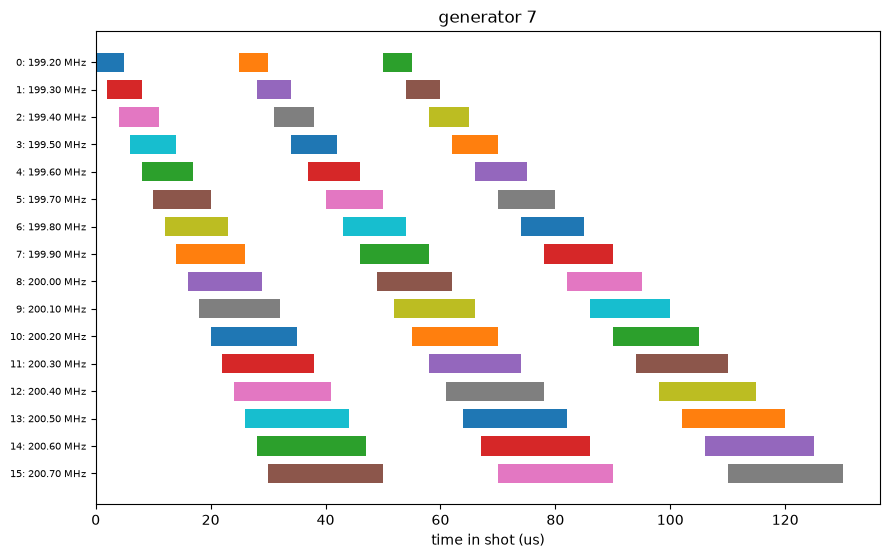

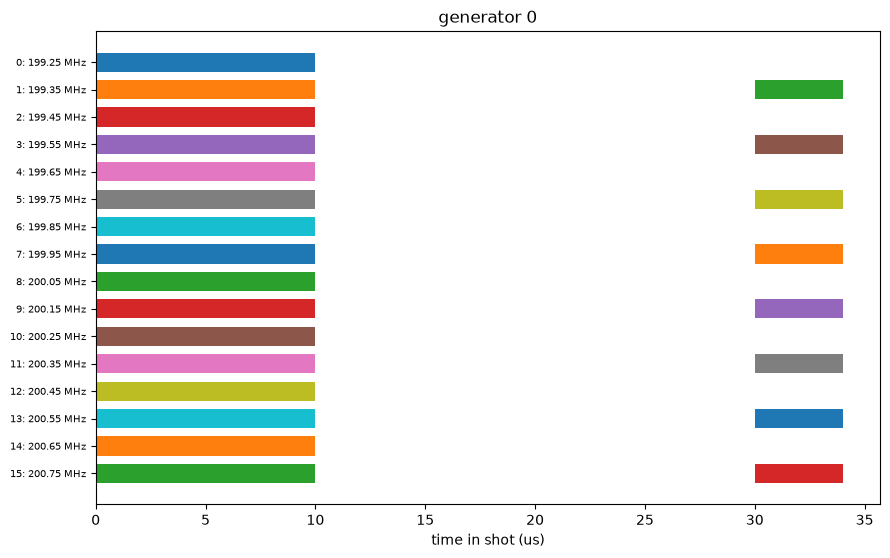

shot length = 130.00 us
generator 7:
      0.000 us  +   2.000 us  ON  tones [0]
      2.000 us  +   2.000 us  ON  tones [0, 1]
      3.999 us  +   1.000 us  ON  tones [0, 1, 2]
      4.999 us  +   1.000 us  ON  tones [1, 2]
      5.999 us  +   2.002 us  ON  tones [1, 2, 3]
      8.001 us  +   2.000 us  ON  tones [2, 3, 4]
     10.000 us  +   1.000 us  ON  tones [2, 3, 4, 5]
     11.000 us  +   1.000 us  ON  tones [3, 4, 5]
     12.000 us  +   2.000 us  ON  tones [3, 4, 5, 6]
     14.000 us  +   2.000 us  ON  tones [4, 5, 6, 7]
     15.999 us  +   1.000 us  ON  tones [4, 5, 6, 7, 8]
     16.999 us  +   1.000 us  ON  tones [5, 6, 7, 8]
  ... 56 more pieces (68 pulses total)
generator 0:
      0.000 us  +  10.000 us  ON  tones [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
     10.000 us  +  19.999 us  off
     29.999 us  +   4.002 us  ON  tones [1, 3, 5, 7, 9, 11, 13, 15]


In [14]:
us = 1.0     # time scale (set 1e5 to stretch for spectrum-analyser viewing)

# ---- generator 7: 16 tones, each with its own start/width, repeated 3 times
tones_A = []
for k in range(16):
    t = Tone(freq=199.2 + 0.1 * k, gain=0.0625, phase=0.0)
    t.train(start_us=2 * k * us, on_us=(5 + k) * us, off_us=20 * us, n=3)
    tones_A.append(t)

# ---- generator 0: 16 different tones, different gain/phase, different timing
tones_B = []
for k in range(16):
    t = Tone(freq=199.25 + 0.1 * k, gain=0.03 + 0.003 * k, phase=22.5 * k)
    t.add(0, 10 * us)
    if k % 2:
        t.add(30 * us, 4 * us)
    tones_B.append(t)

plot_tones(tones_A, "generator 7")
plot_tones(tones_B, "generator 0")

chA = compile_tones(soccfg, gen_ch=7, tones=tones_A)
chB = compile_tones(soccfg, gen_ch=0, tones=tones_B)
shot_16 = [chA, chB]

print(f"shot length = {shot_length_us(shot_16):.2f} us")
print("generator 7:"); show_schedule(chA)
print("generator 0:"); show_schedule(chB)

In [19]:
run_hardware_reps(soc, soccfg, shot_16, n_shots=10000, marker_pin=MARKER_PIN)

In [22]:
run_external_triggered(
    soc, soccfg, shot_16, n_triggers=10, shots_per_trigger=1000, marker_pin=MARKER_PIN,
    on_armed=lambda i: print(f"[{i}] ARMED, waiting for 3.3 V rising edge on external start pin..."),
    on_done=lambda i: print(f"[{i}] trigger received, shot played"))

[0] ARMED, waiting for 3.3 V rising edge on external start pin...
[0] trigger received, shot played
[1] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 0: 2.0 ms
[1] trigger received, shot played
[2] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 1: 2.2 ms
[2] trigger received, shot played
[3] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 2: 0.0 ms
[3] trigger received, shot played
[4] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 3: 15.6 ms
[4] trigger received, shot played
[5] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 4: 17.2 ms
[5] trigger received, shot played
[6] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm gap after trigger 5: 19.3 ms
[6] trigger received, shot played
[7] ARMED, waiting for 3.3 V rising edge on external start pin...
  re-arm 

## 8a. Original notebook test (4 s pulse)

In [12]:
run_original_test(soc, soccfg)

100%|██████████| 1/1 [00:00<00:00, 30.33it/s]


[array([[-1.,  0.],
        [-1.,  0.],
        [ 2.,  0.],
        ...,
        [ 1.,  0.],
        [ 0.,  0.],
        [-2.,  0.]])]

## 8b. Hardware repetition (1000 shots back-to-back, internal start)

In [ ]:
run_hardware_reps(soc, soccfg, shot, n_shots=1000, marker_pin=MARKER_PIN)

## 8c. Python for-loop (one shot per iteration, internal start)

In [13]:
run_python_loop(soc, soccfg, shot, n_shots=20,
                per_shot=lambda i: print("shot", i), marker_pin=MARKER_PIN)

shot 0
shot 1


KeyboardInterrupt: 

## 8d. External trigger: each 3.3 V rising edge plays the shot once
Blocks while waiting for triggers; use the ■ interrupt button to abort. Keep trigger spacing longer than the printed re-arm gap.

In [21]:
run_external_triggered(
    soc, soccfg, shot, n_triggers=10, shots_per_trigger=1, marker_pin=MARKER_PIN,
    on_armed=lambda i: print(f"[{i}] ARMED, waiting for 3.3 V rising edge on external start pin..."),
    on_done=lambda i: print(f"[{i}] trigger received, shot played"))

Traceback (most recent call last):
  File "C:\Users\abhim\anaconda3\envs\qick_env\Lib\site-packages\IPython\core\interactiveshell.py", line 3823, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\abhim\AppData\Local\Temp\ipykernel_48820\2643911058.py", line 2, in <module>
    soc, soccfg, shot, n_triggers=10, shots_per_trigger=1, marker_pin=MARKER_PIN,
                 ^^^^
NameError: name 'shot' is not defined
